In [3]:
import numpy as np
import pandas as pd
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")

df.head()



,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In this notebook, we prepare the volume data of our dataset. We take the volumes as market bid/ask volumes at an instant.

In our model of marked hawkes process, we take the marks as the obtained volumes.

In [6]:
df.columns = [col.strip() for col in df.columns]
print(df.columns) 

Index(['Unnamed: 0', 'system_time', 'midpoint', 'spread', 'buys', 'sells',
       'bids_distance_0', 'bids_distance_1', 'bids_distance_2',
       'bids_distance_3',
       ...
       'asks_market_notional_5', 'asks_market_notional_6',
       'asks_market_notional_7', 'asks_market_notional_8',
       'asks_market_notional_9', 'asks_market_notional_10',
       'asks_market_notional_11', 'asks_market_notional_12',
       'asks_market_notional_13', 'asks_market_notional_14'],
      dtype='object', length=156)


In [7]:
bids_listed = np.array(df[[f"bids_notional_{c}" for c in range(15)]])
bids_volume = np.sum(bids_listed , axis = 1)


In [8]:
asks_listed = np.array(df[[f"asks_notional_{c}" for c in range(15)]])
asks_volume = np.sum(asks_listed, axis=1)

In [10]:
volumes = bids_volume + asks_volume

In [13]:
arr2 = np.copy(volumes)

We are only concerned about the volumes in the instants that a price change occurred.

In [14]:
df = df.drop(df.columns[0],axis=1)
df = df.drop(df.columns[4:],axis=1)
l = list(df.midpoint)
index_set=[]
for i in range(1,len(l)):
    if l[i-1]!=l[i]:
        index_set.append(i)

mask = [0]
for i in range(1,len(l)):
    if l[i-1]!=l[i]:
        mask.append(1)
    else: 
        mask.append(0)

m = np.array(mask)


In [15]:
volumes_in_price_changes = arr2[m==1]

In [16]:
volume_counts_new = {}
for volume in volumes_in_price_changes:
    if volume in volume_counts_new:
        volume_counts_new[volume] += 1
    else:
        volume_counts_new[volume] = 1


Now, we visualize the distributions of the marks by a histogram, and try to fit a distribution to it.

In [17]:
import matplotlib.pyplot as plt

We see a resemblance to a gaussian, when we take the log of the marks.

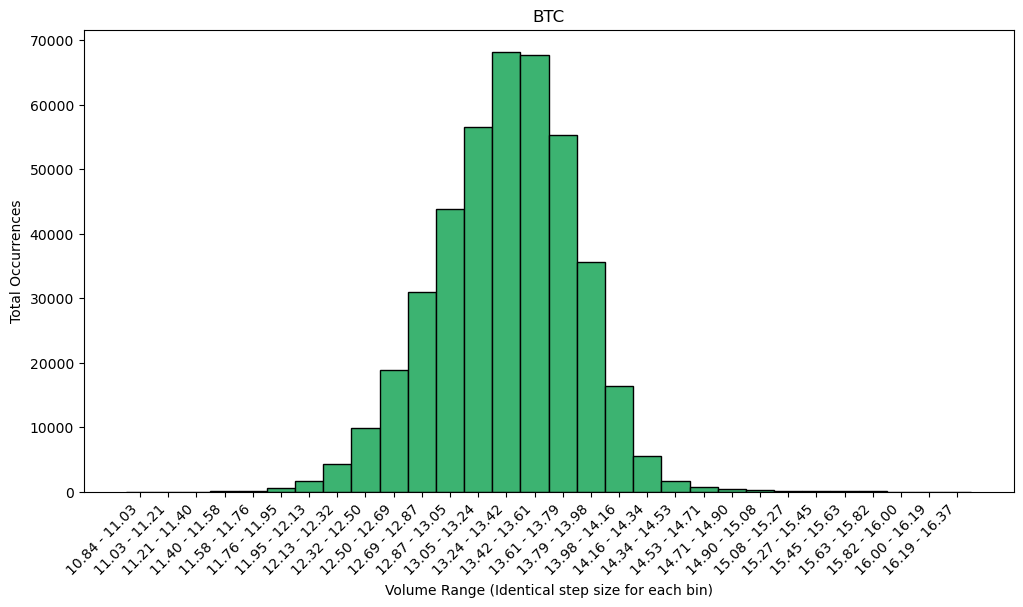

In [18]:
volumes_ = list(np.log(list(volume_counts_new.keys())))
counts = list(volume_counts_new.values())

# 2. Automatically create 10 equal-width bins and sum the counts
# The 'weights' parameter ensures it sums your occurrences instead of just counting the unique keys
bin_sums, bin_edges = np.histogram(volumes_, bins=30, weights=counts)

# 3. Create readable labels for each of the 10 bins
# We round to 2 decimal places for cleaner visual formatting on the chart
bin_labels = [f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(30)]

# 4. Plot the histogram using a bar chart
plt.figure(figsize=(12, 6))

# width=1.0 makes the bars touch, which is the standard look for a continuous histogram
plt.bar(bin_labels, bin_sums, width=1.0, color='mediumseagreen', edgecolor='black')

plt.title("BTC")
plt.xlabel("Volume Range (Identical step size for each bin)")
plt.ylabel("Total Occurrences")

# Rotate the x-axis labels so they are readable
plt.xticks(rotation=45, ha='right') 

# Adjust layout to prevent labels from being cut off

plt.show()

In [ ]:
mean = np.mean(np.log(list(volume_counts_new.keys())))


In [21]:
print(mean)

13.329567797401769


We will be using the mean of the volumes in the theoretical parameter estimation.

In [22]:
np.savetxt("volumes_and_mask", np.stack((volumes,mask), axis = 1), fmt = "%f,%d")